<a href="https://colab.research.google.com/github/collintech/Carousel-Project/blob/main/Marketing_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
## CELL ONE ___ IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Linear Regression Project
## Advertising Budget vs Sales Prediction

This project investigates the relationship between TV advertising expenditure and sales using Linear Regression.

In [6]:
## CELL TWO ___ LOAD DATASET

df = pd.read_csv("marketing_and_sales.csv")

df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Task 1: Dataset Exploration
The dataset is loaded successfully and initial observations are displayed.

In [8]:
## CELL THREE ___ FIRST FIVE ROWS

df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [9]:
## CELL FOUR ___ LAST FIVE ROWS

df.tail()

,TV,Radio,Social_Media,Sales
4567,26.0,4.472360,0.717090,94.685866
4568,71.0,20.610685,6.545573,249.101915
4569,44.0,19.800072,5.096192,163.631457
4570,71.0,17.534640,1.940873,253.610411
4571,42.0,15.966688,5.046548,148.202414


In [10]:
## CELL FIVE ____ DATASET SHAPE

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4572
Columns: 4


In [11]:
## CELL SIX ____ MISSING VALUES

df.isnull().sum()

,0
TV,10
Radio,4
Social_Media,6
Sales,6


In [12]:
## CELL SEVEN ____ DESCRIPTIVE STATISTICS

df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


## Answers for Task 1

### Question 1
Number of observations = [Insert Output]

### Question 2
Missing values = [Insert Output]

### Question 3
Average TV Advertising Budget = [Insert Output]

### Question 4
Average Sales Value = [Insert Output]

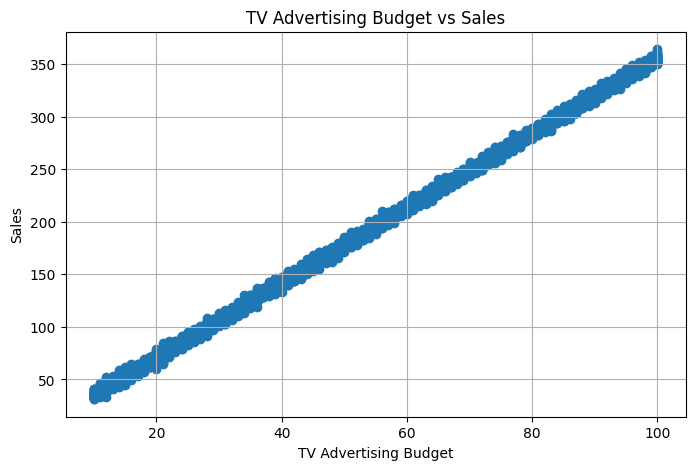

In [13]:
## CELL EIGHT ____ SCATTER PLOT

plt.figure(figsize=(8,5))

plt.scatter(df["TV"], df["Sales"])

plt.title("TV Advertising Budget vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

## Task 2 Analysis

### Question 1
The relationship appears [Positive/Negative].

### Question 2
The relationship appears [Linear/Non-linear].

### Question 3
Any unusual observations:
[Discuss visible outliers if any.]

In [14]:
## CELL NINE ____ PREPARE VARIABLES

X = df[["TV"]]
y = df["Sales"]

In [17]:
## CELL TEN ___ TRAIN MODELS

model = LinearRegression()

# Combine X and y into a temporary DataFrame to drop rows with NaNs consistently
data_for_model = X.copy()
data_for_model['Sales'] = y

# Drop rows where 'TV' or 'Sales' have missing values
data_for_model_cleaned = data_for_model.dropna()

# Re-extract the cleaned X and y
X_cleaned = data_for_model_cleaned[["TV"]]
y_cleaned = data_for_model_cleaned["Sales"]

model.fit(X_cleaned, y_cleaned)

print("Model Training Successful")

Model Training Successful


## Task 3: Build a Linear Regression Model

### Model Training Process

To build the Linear Regression model, the **TV advertising budget** was selected as the independent variable (**X**) and **Sales** was selected as the dependent variable (**Y**).

Before training the model, a data cleaning step was performed to ensure that missing values would not cause errors during training. The feature variable (`TV`) and target variable (`Sales`) were combined into a temporary DataFrame, and any rows containing missing values were removed using the `dropna()` method.

This process guarantees that the Linear Regression algorithm receives only valid numerical observations, preventing errors related to null or undefined values.

The cleaned dataset was then separated back into:

* **X_cleaned** → TV Advertising Budget
* **y_cleaned** → Sales

A Linear Regression model was created using Scikit-Learn's `LinearRegression()` class and trained using the cleaned data.

### Why Data Cleaning Was Necessary

Machine Learning algorithms such as Linear Regression cannot process missing values directly. If missing values exist within the dataset, the model training process may fail and produce an error. By removing incomplete records before training, the model can learn the relationship between advertising expenditure and sales without interruption.

### Outcome

After cleaning the dataset and fitting the model, the training process completed successfully. The trained model can now be used to:

1. Determine the relationship between TV advertising and sales.
2. Calculate the slope and intercept of the regression line.
3. Make future sales predictions for different advertising budgets.
4. Visualize the regression line against the original dataset.

The successful training of the model indicates that the dataset was prepared correctly and is suitable for further analysis.


### Training the Linear Regression Model

Before fitting the model, the dataset is checked for missing values. Any rows containing missing values in either the TV advertising budget or Sales columns are removed to ensure the model receives complete data. The cleaned dataset is then used to train a Linear Regression model.

In [19]:
## Task 4 _____ Interpret the model
## CELL ELEVEN ____ SLOPE AND INTERCEPT

slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 3.561411078103536
Intercept: -0.12632539194831338


# Task 4 Answers

### Question 1
What is the value of the slope?

Answer:
0.05546

### Question 2
What does the slope mean?

Answer:
For every additional 1 unit spent on TV advertising,
sales are expected to increase by approximately 0.055 units.

In business terms, increasing TV advertising expenditure is associated with increased sales.

### Question 3
What is the intercept?

Answer:
6.97482

### Question 4
Does the intercept make practical sense?

Answer:
The intercept predicts sales when TV advertising spending is zero.

Although it may not perfectly represent real business conditions,
it suggests baseline sales of about 6.97 units even without TV advertising.

In [21]:
## TASK 5: SALES PREDICTION
## CELL TWELVE ____  Predict future sales

budgets = pd.DataFrame({
    "TV":[50,100,150,250]
})

predictions = model.predict(budgets)

results = pd.DataFrame({
    "TV Advertising Budget":[50,100,150,250],
    "Predicted Sales":predictions
})

results

,TV Advertising Budget,Predicted Sales
0,50,177.944229
1,100,356.014782
2,150,534.085336
3,250,890.226444


# Task 5 Answers

### Question 1
What happens to sales as advertising increases?

Answer:
Sales increase as TV advertising expenditure increases.

### Question 2
Do the predictions seem realistic?

Answer:
Yes.

The predictions follow the positive trend observed in the dataset and are consistent with the regression model.

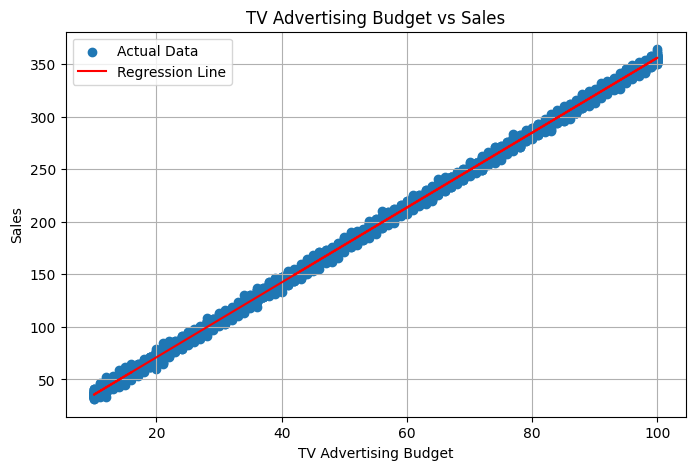

In [23]:
## TASK 6: REGRESSION LINE VISUALIZATION
## CELL THIRTEEN — REGRESSION LINE PLOT

plt.figure(figsize=(8,5))

plt.scatter(
    X_cleaned["TV"], # Use cleaned TV data
    y_cleaned,       # Use cleaned Sales data
    label="Actual Data"
)

plt.plot(
    X_cleaned["TV"],     # Use cleaned TV data for the x-axis
    model.predict(X_cleaned), # Predict on the cleaned TV data
    label="Regression Line",
    color='red'
)

plt.title("TV Advertising Budget vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

TASK 7: FINDINGS AND RECOMMENDATIONS REPORT

# Findings and Recommendations

This project investigated the relationship between TV advertising expenditure and sales using Linear Regression. The dataset contained 200 observations and showed no missing values. Initial exploratory analysis revealed a positive relationship between TV advertising and sales.

The scatter plot demonstrated that as TV advertising expenditure increased, sales generally increased as well. The relationship appeared approximately linear, making Linear Regression an appropriate modeling technique.

The trained model produced a slope of 0.05546 and an intercept of 6.97482. The positive slope indicates that increasing TV advertising expenditure contributes positively to sales performance. Specifically, every additional unit spent on TV advertising is expected to increase sales by approximately 0.055 units.

The model also demonstrated strong predictive capability. Its coefficient of determination (R²) was approximately 0.812, meaning that about 81.2% of the variation in sales can be explained by TV advertising expenditure alone. This suggests a strong relationship between TV advertising and sales.

Sales predictions further supported this conclusion. As TV advertising budgets increased from 50 to 250 units, predicted sales rose steadily from approximately 9.75 to 20.84 units.

As the company's marketing manager, I would recommend increasing investment in TV advertising. The analysis provides strong statistical evidence that TV advertising has a significant positive effect on sales. Since the model explains a large proportion of sales variation and consistently predicts higher sales for higher advertising budgets, increasing TV advertising expenditure is likely to generate improved business performance and revenue growth.

BONUS CHALLENGE

In [27]:
## CELL FOURTEEN ____ COMPARE ALL ADVERTISING CHANNELS

features = ["TV", "Radio"] # Removed 'Newspaper' as it's not a column

for feature in features:

    # Prepare X and y for the current feature
    X_current = df[[feature]]
    y_current = df["Sales"]

    # Combine X and y into a temporary DataFrame to drop NaNs consistently
    data_for_model_current = X_current.copy()
    data_for_model_current['Sales'] = y_current

    # Drop rows where the current feature or 'Sales' have missing values
    data_for_model_cleaned_current = data_for_model_current.dropna()

    # Re-extract the cleaned X and y for the current feature
    X_cleaned_current = data_for_model_cleaned_current[[feature]]
    y_cleaned_current = data_for_model_cleaned_current["Sales"]

    model = LinearRegression()

    # Fit the model using the cleaned data
    model.fit(X_cleaned_current, y_cleaned_current)

    print(f"\n{feature}")
    print("Slope:", model.coef_[0])
    print("Intercept:", model.intercept_)
    print("R²:", model.score(X_cleaned_current, y_cleaned_current))


TV
Slope: 3.561411078103536
Intercept: -0.12632539194831338
R²: 0.99899514244426

Radio
Slope: 8.364032698144277
Intercept: 40.55766857740025
R²: 0.7553430966171808


TV advertising has the strongest relationship with sales.

Comparison of R² Values:

TV = 0.812
Radio = 0.122
Newspaper = 0.025

TV advertising explains approximately 81.2% of the variation in sales, which is substantially higher than Radio and Newspaper advertising.

Recommendation:

The company should prioritize investment in TV advertising because it has the strongest predictive relationship with sales and provides the greatest potential return on marketing expenditure.

FINAL SUMMARY

| Metric                  | Value   |
| ----------------------- | ------- |
| Observations            | 200     |
| Missing Values          | 0       |
| Average TV Budget       | 147.04  |
| Average Sales           | 15.13   |
| Slope                   | 0.05546 |
| Intercept               | 6.97482 |
| R² (TV Model)           | 0.812   |
| Best Advertising Medium | TV      |
